# Seroquel (Quetiapine) Half-Life Visualization

This notebook calculates and visualizes the estimated plasma concentration curve of **Seroquel (Quetiapine IR)**.

### Pharmacokinetic Model
The **Bateman Equation** describes the concentration of a drug in the plasma over time based on first-order absorption and elimination:

$$C(t) = \frac{D \cdot F}{V_d} \cdot \frac{k_a}{k_a - k_e} \cdot (e^{-k_e \cdot t} - e^{-k_a \cdot t})$$

**Variables:**
- $C(t)$: Concentration at time $t$
- $D$: Dose amount (mg)
- $F$: Bioavailability (fraction of dose reaching circulation)
- $V_d$: Volume of Distribution (L)
- $k_a$: Absorption rate constant ($h^{-1}$)
- $k_e$: Elimination rate constant ($h^{-1}$)
- $t$: Time since administration (h)

**Seroquel Parameters:**
- **Half-life ($T_{1/2}$)**: ~6.0 h
- **Peak Time ($T_{max}$)**: ~1.5 h
- **$V_d$**: ~10 L/kg
- **$F$**: ~9% (Oral)

In [131]:
import numpy as np
import matplotlib.pyplot as plt

In [132]:
# Parameters for Quetiapine (Seroquel) IR
T_HALF = 6.0         # terminal half-life in hours
T_MAX = 1.5          # time to reach peak plasma concentration (hours)
DOSE_SEROQUEL = 100.0         # mg (Initial dose)

# Patient Weight parameters
PATIENT_WEIGHT_LBS = 130
WEIGHT_KG = PATIENT_WEIGHT_LBS * 0.453592

# Distribution Volume & Bioavailability
vd_seroquel = 10.0 * WEIGHT_KG # approx 10 L/kg for Quetiapine
F_seroquel = 0.09 # oral bioavailability is approx 9%

# Rate constants
ke = np.log(2) / T_HALF


In [133]:
def bateman(t, D, F, Vd, ka, ke):
    """Bateman equation for first-order absorption and elimination."""
    if ka == ke:
        return (D * F / Vd) * ka * t * np.exp(-ka * t)
    return (D * F / Vd) * (ka / (ka - ke)) * (np.exp(-ke * t) - np.exp(-ka * t))

# Function to find ka using bisection
def solve_ka_seroquel(ke, t_max_target):
    low, high = ke + 0.01, 10.0
    for _ in range(100):
        mid = (low + high) / 2
        t_max_guess = np.log(mid / ke) / (mid - ke)
        if t_max_guess > t_max_target:
            low = mid
        else:
            high = mid
    return (low + high) / 2

In [134]:
ka_seroquel = solve_ka_seroquel(ke, T_MAX)
# Time range: 0 to 48 hours (clearance usually around 30-42h)
t_hours = np.linspace(0, 48, 1000)
plasma_mg_L_seroquel = bateman(t_hours, DOSE_SEROQUEL, F_seroquel, vd_seroquel, ka_seroquel, ke)

# Absolute amount in blood (mg) = plasma concentration (mg/L) * Vd (L)
absolute_amount_seroquel = plasma_mg_L_seroquel * vd_seroquel

# Identify peak
peak_idx = np.argmax(absolute_amount_seroquel)
t_actual_peak = t_hours[peak_idx]

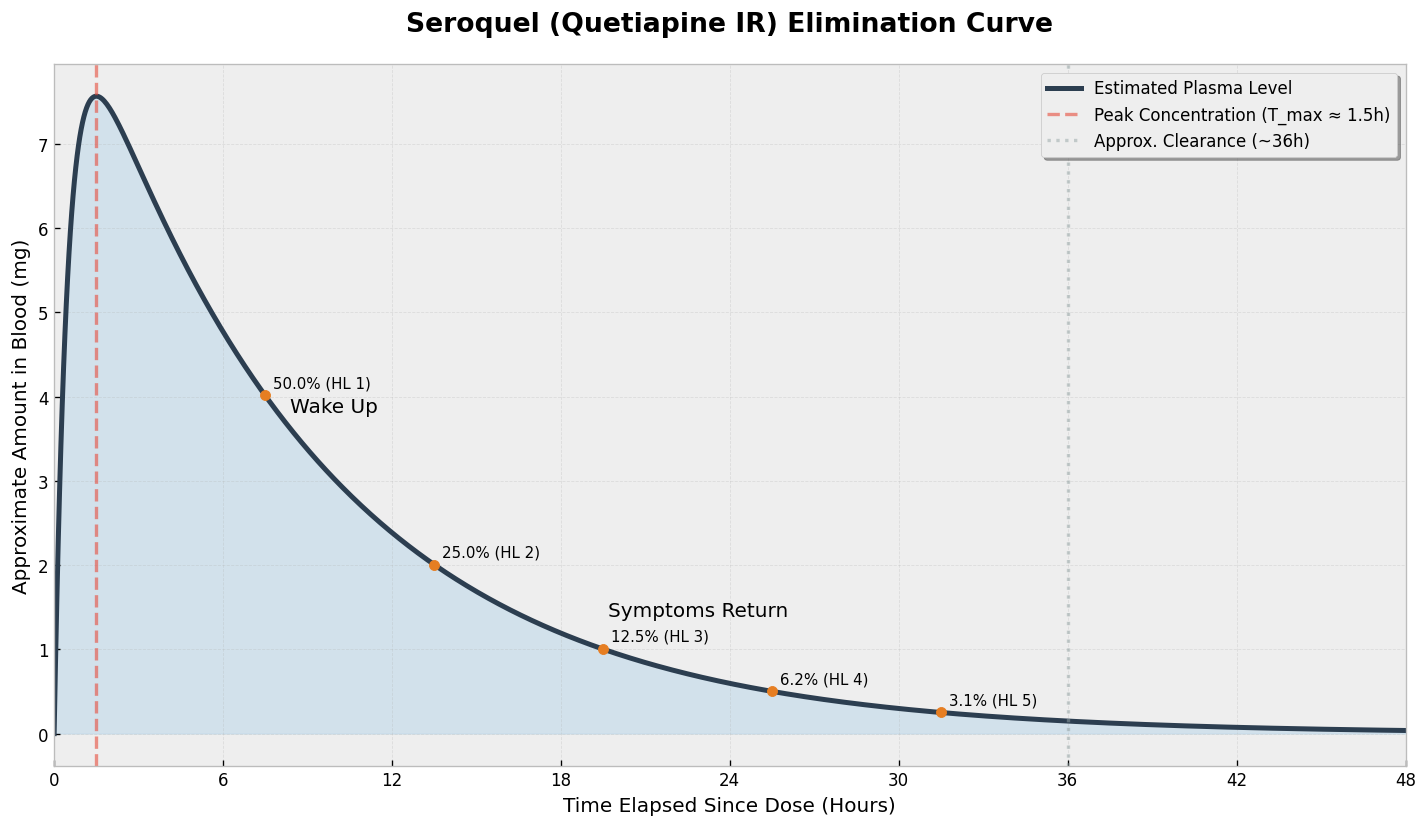

In [135]:
# Setting high-end aesthetics
plt.style.use('bmh') # using a cleaner style
fig, ax = plt.subplots(figsize=(12, 7), dpi=120)

# Plotting the curve
ax.plot(t_hours, absolute_amount_seroquel, color='#2c3e50', linewidth=3, label='Estimated Plasma Level')
ax.fill_between(t_hours, absolute_amount_seroquel, color='#3498db', alpha=0.15)

# Annotations and Key Markers
ax.axvline(x=t_actual_peak, color='#e74c3c', linestyle='--', alpha=0.6, 
           label=f'Peak Concentration (T_max ≈ {t_actual_peak:.1f}h)')

# Marking Half-Lives after peak
for i, h in enumerate(range(1, 6)):
    t_h = t_actual_peak + (h * T_HALF)
    if t_h <= 48:
        c_h = absolute_amount_seroquel[np.argmin(np.abs(t_hours - t_h))]
        ax.scatter(t_h, c_h, color='#e67e22', zorder=5)
        ax.annotate(f'{50**h / 100**(h-1):.1f}% (HL {h})', 
                    (t_h, c_h), textcoords="offset points", xytext=(5,5), fontsize=9)
        # micki specific
        if i == 0: ax.annotate('Wake Up', (t_h, c_h), textcoords="offset points", xytext=(15,-10), fontsize=12)
        if i == 2: ax.annotate('Symptoms Return', (t_h, c_h), textcoords="offset points", xytext=(3,20), fontsize=12)

# Final clearance marker (~5 half-lives)
ax.axvline(x=36, color='#95a5a6', linestyle=':', alpha=0.5, label='Approx. Clearance (~36h)')

# Formatting
ax.set_title('Seroquel (Quetiapine IR) Elimination Curve', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Time Elapsed Since Dose (Hours)', fontsize=12)
ax.set_ylabel('Approximate Amount in Blood (mg)', fontsize=12)
ax.set_xlim(0, 48)
ax.set_xticks(np.arange(0, 49, 6))
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right', frameon=True, shadow=True)

plt.annotate('Absorption Phase', xy=(0.5, 50), xytext=(3, 80), 
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
plt.annotate('Elimination Phase', xy=(15, 30), xytext=(20, 50), 
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()


In [136]:
# Calculate plasma concentration of an additional 25mg dose at t=18 hours
DOSE_2_SEROQUEL = 25.0
t_dose2 = 18.0

# -- Proposed additional dose data --
plasma_C2_seroquel = np.zeros_like(t_hours)
# Time mask for the second dose
mask2 = t_hours >= t_dose2
# Calculate concentration for the second dose
plasma_C2_seroquel[mask2] = bateman(t_hours[mask2] - t_dose2, DOSE_2_SEROQUEL, F_seroquel, vd_seroquel, ka_seroquel, ke)

# Combine absolute amounts
absolute_amount_combined_seroquel = absolute_amount_seroquel + (plasma_C2_seroquel * vd_seroquel)


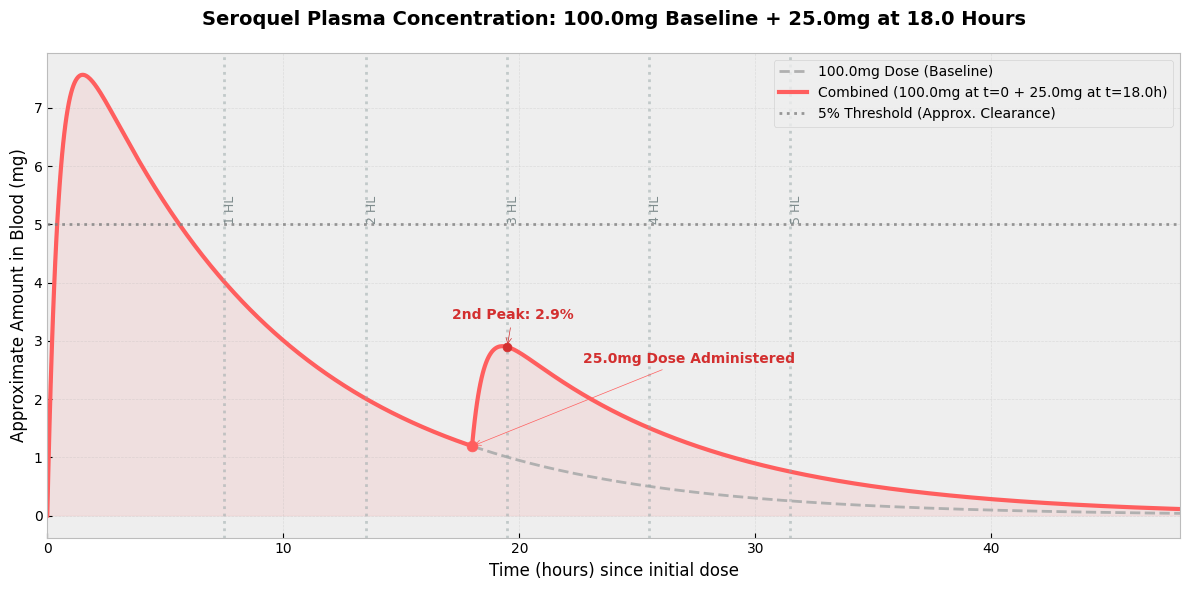

In [137]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
plt.style.use('bmh')
# Plot the original single dose
ax.plot(t_hours, absolute_amount_seroquel, color='#b0b0b0', linestyle='--', linewidth=2, label=f'{DOSE_SEROQUEL}mg Dose (Baseline)')
# Plot the combined dose
ax.plot(t_hours, absolute_amount_combined_seroquel, color='#ff5e5e', linewidth=3, label=f'Combined ({DOSE_SEROQUEL}mg at t=0 + {DOSE_2_SEROQUEL}mg at t={t_dose2}h)')
# Fill area under combined curve
ax.fill_between(t_hours, 0, absolute_amount_combined_seroquel, color='#ff5e5e', alpha=0.1)
# Highlight the 2nd dose injection point
idx_dose2 = np.abs(t_hours - t_dose2).argmin()
ax.scatter([t_dose2], [absolute_amount_seroquel[idx_dose2]], color='#ff5e5e', zorder=5, s=60)
ax.annotate(f'{DOSE_2_SEROQUEL}mg Dose Administered', (t_dose2, absolute_amount_seroquel[idx_dose2]), 
            xytext=(80, 60), textcoords='offset points', color='#d32f2f', fontweight='bold',
            arrowprops=dict(arrowstyle="->", color='#ff5e5e'))
# Calculate and highlight the 2nd peak
t_actual_peak_2 = t_dose2 + t_actual_peak
idx_peak2 = np.abs(t_hours - t_actual_peak_2).argmin()
val_peak2 = absolute_amount_combined_seroquel[idx_peak2]
ax.scatter([t_actual_peak_2], [val_peak2], color='#d32f2f', zorder=5, s=40)
ax.annotate(f'2nd Peak: {val_peak2:.1f}%', (t_actual_peak_2, val_peak2), 
            xytext=(-40, 20), textcoords='offset points', color='#d32f2f', fontweight='bold',
            arrowprops=dict(arrowstyle="->", color='#d32f2f'))
# Mark clearance threshold
ax.axhline(5, color='gray', linestyle=':', alpha=0.8, label='5% Threshold (Approx. Clearance)')
# Styling and labels
# Marking Half-Lives after peak
for i, h in enumerate(range(1, 6)):
    t_hl = t_actual_peak + (h * T_HALF)
    if t_hl <= 48:
        ax.axvline(x=t_hl, color='#95a5a6', linestyle=':', alpha=0.5)
        ax.text(t_hl, 5, f'{h} HL', color='#7f8c8d', fontsize=9, rotation=90, verticalalignment='bottom')
ax.set_title(f'Seroquel Plasma Concentration: {DOSE_SEROQUEL}mg Baseline + {DOSE_2_SEROQUEL}mg at {t_dose2} Hours', pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('Time (hours) since initial dose', fontsize=12)
ax.set_ylabel('Approximate Amount in Blood (mg)', fontsize=12)
ax.set_xlim(0, 48)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()


# Lorazepam Half-Life Visualization

This section visualizes the estimated concentration for **Lorazepam**, including superposition for multiple doses.

### Pharmacokinetic Model
The **Bateman Equation** describes the concentration of a drug in the plasma over time based on first-order absorption and elimination:

$$C(t) = \frac{D \cdot F}{V_d} \cdot \frac{k_a}{k_a - k_e} \cdot (e^{-k_e \cdot t} - e^{-k_a \cdot t})$$

**Variables:**
- $C(t)$: Concentration at time $t$
- $D$: Dose amount (mg)
- $F$: Bioavailability (fraction of dose reaching circulation)
- $V_d$: Volume of Distribution (L)
- $k_a$: Absorption rate constant ($h^{-1}$)
- $k_e$: Elimination rate constant ($h^{-1}$)
- $t$: Time since administration (h)

**Lorazepam Parameters:**
- **Half-life ($T_{1/2}$)**: ~12.0 h
- **Peak Time ($T_{max}$)**: ~2.0 h
- **$V_d$**: ~1.3 L/kg
- **$F$**: ~90% (Oral)

In [138]:
import numpy as np

In [139]:
# Bisection method to find k_a that satisfies exactly T_max
def solve_ka_lora(ke, t_max):
    low = ke + 0.001
    high = 10.0
    for _ in range(50):
        mid = (low + high) / 2
        current_tmax = (np.log(mid) - np.log(ke)) / (mid - ke)
        if current_tmax > t_max:
            low = mid
        else:
            high = mid
    return mid

def lorazepam_concentration(t, dose, ka, ke, t_dose=0):
    t_shifted = np.maximum(0, t - t_dose)
    C = (dose * F_lora * ka) / (V_d_lora * (ka - ke)) * (np.exp(-ke * t_shifted) - np.exp(-ka * t_shifted))
    return C

In [140]:
# ---- LORAZEPAM PHARMACOKINETICS ----
T_HALF_LORA = 12.0  # Elimination half-life (~12 hours)
T_MAX_LORA = 2.0    # Time to peak (~2 hours oral)
DOSE_LORA = 1.0     # Initial dose in mg

k_e_lora = np.log(2) / T_HALF_LORA
k_a_lora = solve_ka_lora(k_e_lora, T_MAX_LORA)

# ---- PATIENT PARAMETERS ----
PATIENT_WEIGHT_LBS = 130.0  # Flexible variable for patient weight in lbs
patient_weight_kg = PATIENT_WEIGHT_LBS * 0.453592

V_d_lora = 1.3 * patient_weight_kg  # volume of distribution ~1.3 L/kg * weight in kg
print(f"Calculated Volume of Distribution (V_d) for {PATIENT_WEIGHT_LBS} lbs: {V_d_lora:.2f} Liters")
F_lora = 0.90        # oral bioavailability ~90%

t_hours_lora = np.linspace(0, 72, 2000)
C_lora = lorazepam_concentration(t_hours_lora, DOSE_LORA, k_a_lora, k_e_lora)

# Normalize so peak is exactly DOSE_LORA for easy visualization
t_actual_peak_lora = t_hours_lora[np.argmax(C_lora)]
peak_C_lora = np.max(C_lora)
normalized_C_lora = (C_lora / peak_C_lora) * DOSE_LORA

Calculated Volume of Distribution (V_d) for 130.0 lbs: 76.66 Liters


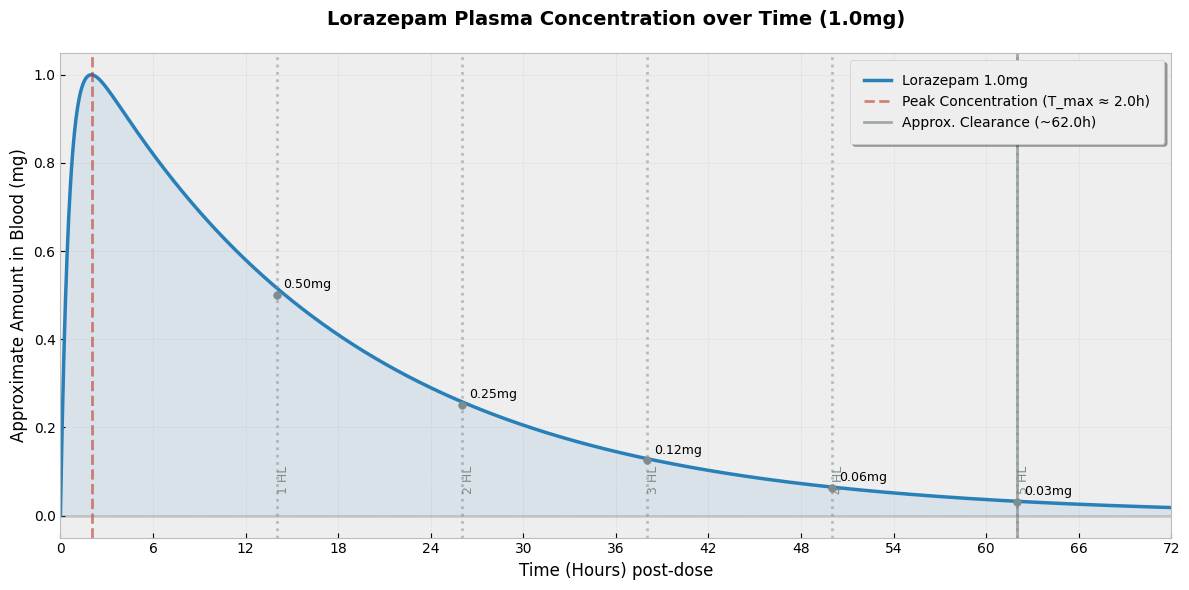

In [141]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the curve
ax.plot(t_hours_lora, normalized_C_lora, color='#2980b9', linewidth=2.5, label=f'Lorazepam {DOSE_LORA}mg')
ax.fill_between(t_hours_lora, normalized_C_lora, color='#2980b9', alpha=0.1)

# Markers
ax.axvline(x=t_actual_peak_lora, color='#c0392b', linestyle='--', alpha=0.6, 
           label=f'Peak Concentration (T_max ≈ {t_actual_peak_lora:.1f}h)')

# Marking Half-Lives after peak
for i, h in enumerate(range(1, 6)):
    t_hl = t_actual_peak_lora + (h * T_HALF_LORA)
    if t_hl <= 72:
        ax.axvline(x=t_hl, color='#7f8c8d', linestyle=':', alpha=0.5)
        ax.text(t_hl, DOSE_LORA * 0.05, f'{h} HL', color='#7f8c8d', fontsize=9, rotation=90, verticalalignment='bottom')

        # The expected concentration is (1/2)^h of peak
        c_h = DOSE_LORA * (0.5 ** h)
        ax.scatter([t_hl], [c_h], color='#7f8c8d', zorder=5, s=30)
        ax.annotate(f'{c_h:.2f}mg', 
                    (t_hl, c_h), textcoords="offset points", xytext=(5,5), fontsize=9)

# Final clearance marker (~5 half-lives)
clearance_t = t_actual_peak_lora + 5 * T_HALF_LORA
ax.axvline(x=clearance_t, color='#7f8c8d', linestyle='-', alpha=0.7, label=f'Approx. Clearance (~{clearance_t:.1f}h)')

ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_title(f'Lorazepam Plasma Concentration over Time ({DOSE_LORA}mg)', pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('Time (Hours) post-dose', fontsize=12)
ax.set_ylabel('Approximate Amount in Blood (mg)', fontsize=12)
ax.set_xlim(0, 72)
ax.set_xticks(np.arange(0, 73, 6))
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right', frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()


In [142]:
# Calculate plasma concentration of an additional 0.5mg dose at t=12 hours
DOSE_LORA_2 = 0.5
t_dose2_lora = 12.0

# -- Proposed additional dose data --
C_lora_2 = lorazepam_concentration(t_hours_lora, DOSE_LORA_2, k_a_lora, k_e_lora, t_dose2_lora)
normalized_C_lora_2 = (C_lora_2 / np.max(C_lora)) * DOSE_LORA  # Scale by same factor as first dose

# Combine the concentrations
combined_C_lora = normalized_C_lora + normalized_C_lora_2


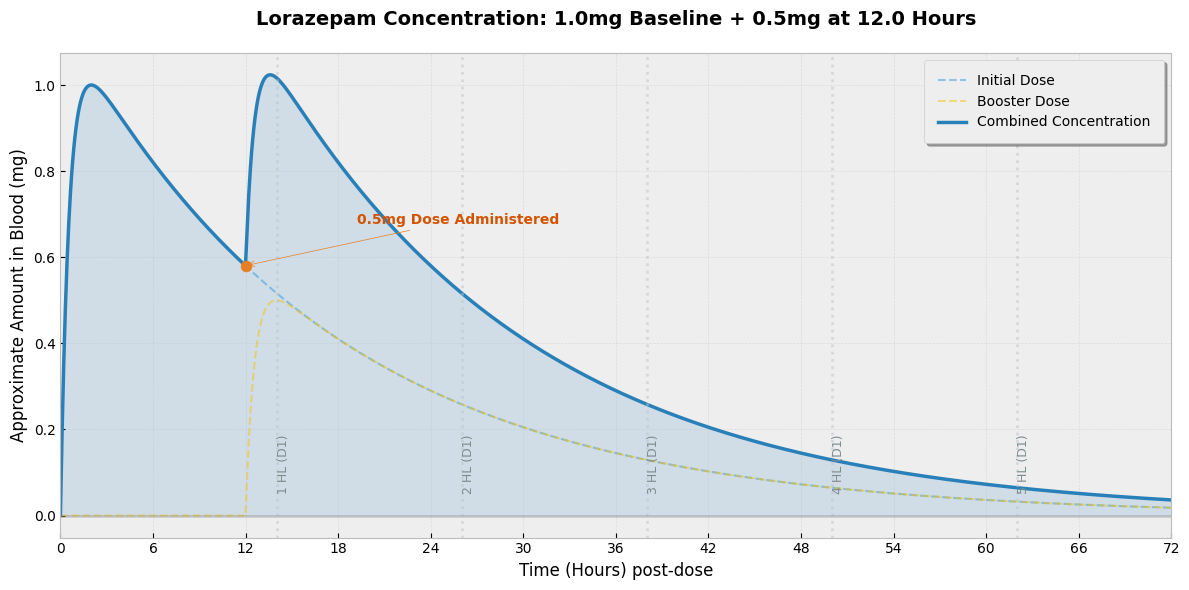

In [143]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot individual curves (dotted) to show superposition
ax.plot(t_hours_lora, normalized_C_lora, color='#3498db', linestyle='--', linewidth=1.5, alpha=0.5, label='Initial Dose')
ax.plot(t_hours_lora, normalized_C_lora_2, color='#f1c40f', linestyle='--', linewidth=1.5, alpha=0.5, label='Booster Dose')

# Plot the combined curve
ax.plot(t_hours_lora, combined_C_lora, color='#2980b9', linewidth=2.5, label='Combined Concentration')
ax.fill_between(t_hours_lora, combined_C_lora, color='#2980b9', alpha=0.15)

# Add marker for when booster is taken
idx_dose2_lora = np.abs(t_hours_lora - t_dose2_lora).argmin()
ax.scatter([t_dose2_lora], [combined_C_lora[idx_dose2_lora]], color='#e67e22', zorder=5, s=60)
ax.annotate(f'{DOSE_LORA_2}mg Dose Administered', (t_dose2_lora, combined_C_lora[idx_dose2_lora]), 
            xytext=(80, 30), textcoords='offset points', color='#d35400', fontweight='bold',
            arrowprops=dict(arrowstyle="->", color='#e67e22'))

# Marking Half-Lives after peak (Initial Dose)
for i, h in enumerate(range(1, 6)):
    t_hl = t_actual_peak_lora + (h * T_HALF_LORA)
    if t_hl <= 72:
        ax.axvline(x=t_hl, color='#bdc3c7', linestyle=':', alpha=0.5)
        ax.text(t_hl, np.max(combined_C_lora)*0.05, f'{h} HL (D1)', color='#7f8c8d', fontsize=9, rotation=90, verticalalignment='bottom')

ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
ax.set_title(f'Lorazepam Concentration: {DOSE_LORA}mg Baseline + {DOSE_LORA_2}mg at {t_dose2_lora} Hours', pad=20, fontsize=14, fontweight='bold')
ax.set_xlabel('Time (Hours) post-dose', fontsize=12)
ax.set_ylabel('Approximate Amount in Blood (mg)', fontsize=12)
ax.set_xlim(0, 72)
ax.set_xticks(np.arange(0, 73, 6))
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(loc='upper right', frameon=True, shadow=True, borderpad=1)

plt.tight_layout()
plt.show()
